A script to compute the zonal wavenumber of the Lamb wave in a numerical simulation.
Use this to examine the regime we are in, relative to the wavenumbers of acoustic and gravity waves

In [72]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from functions import *

In [73]:

### SE ###
#case = 'CAM_6_4_089_ne30_ne30_mg16_L25_ztop12.5km_dz500m_pressure_perturb'
#case = 'CAM_6_4_089_ne30_ne30_mg16_L50_ztop25km_dz500m_pressure_perturb'
#case = 'CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb'
#case = 'CAM_6_4_089_ne30_ne30_mg16_L200_ztop100km_dz500m_pressure_perturb'
#run_base = '/glade/derecho/scratch/nforcone/'
#nc_file = case + '.cam.h0i.0001-01-01-00000.nc'

### FV3 ###
#case = 'cam_6_4_095_lamb_fv3_C96_ztop_12.5km_dt_1min'
#case = 'cam_6_4_095_lamb_fv3_C96_ztop_25km_dt_1min'
#case = 'cam_6_4_095_lamb_fv3_C96_ztop_50km_dt_1min'
#case = 'cam_6_4_095_lamb_fv3_C96_ztop_100km_dt_1min'
#run_base = "/glade/derecho/scratch/timand/"
#nc_file = case + '.cam.h0i.0001-01-01-00000_p_pert.regrid.1x1.nc'

### MPAS ###
#case = 'cam_6_4_161.MPAS120.L25.top_12.5km.fadiab.pressure_perturb'
#case = 'cam_6_4_161.MPAS120.L50.top_25km.fadiab.pressure_perturb'
case = 'cam_6_4_161.MPAS120.L100.top_50km.fadiab.pressure_perturb'
#case = 'cam_6_4_161.MPAS120.L200.top_100km.fadiab.pressure_perturb'
run_base = '/glade/derecho/scratch/cjablono/'    
#nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.nc'

# Variants for 50 km model top
#nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.50hPa.nc'
#nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.0.cpair_default.50hPa.nc'
#nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_default.1hPa.nc'
nc_file = case + '.cam.h0i.0001-01-01-00000.1min.regrid.1x1.18h.epssm_0.1.cpair_2008.50hPa.nc'


# For all runs:
run_path = run_base + case + '/run/' + nc_file
nc = Dataset(run_path, 'r')


In [74]:
time = nc['time'][:]
lat_deg = nc['lat'][:] 
lon_deg = nc['lon'][:] 

# Work in radians
lat = lat_deg*np.pi/180
lon = lon_deg*np.pi/180

LON, LAT = np.meshgrid(lon_deg, lat_deg)

print(np.min(lon))
print(np.max(lon))
print(np.min(lat))
print(np.max(lat))

0.0
6.265732014659642
-1.5707963267948966
1.5707963267948966


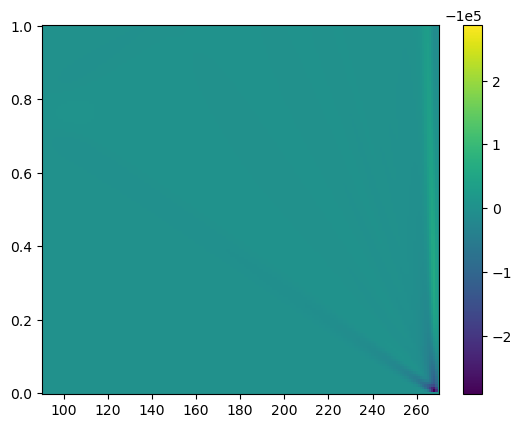

In [75]:
# Choose the field and plot a Hovmuller diagram at the equator. Assume a 3D field (fixed height), not 4D
lat_ind = 90

field = 'U850'
p0 = 1e5
data = nc[field][:, lat_ind, :] - p0

X, T = np.meshgrid(lon_deg, time)

plt.figure()
plt.pcolormesh(X, T, data)
plt.xlim([90,270])
plt.colorbar()
plt.show()


In [76]:
# Compute the wave speed!
lon_vals = np.array([120, 140, 160, 180, 200, 220, 240, 260])
lamb_times, lamb_speed = find_lamb_wave(nc[field][:], time, lat_ind, lon_vals, 'min', 0.0001)
print(lamb_speed)

313.5227893959434
